<a href="https://colab.research.google.com/github/Mizuko821/master_thesis/blob/main/%E5%AE%9F%E9%A8%931_GRL%2B%E3%83%9E%E3%83%AB%E3%83%81%E3%82%BF%E3%82%B9%E3%82%AF%E3%83%A2%E3%83%87%E3%83%AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 準備

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers torch
!pip install accelerate -U
!pip install fugashi ipadic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 600.9/600.9 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 63.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for ipadic: filename=ipadic-1.0.0-py3-none-any.whl size=13556704 sha256=76033a84e2ca8979c937269bce87bca8b0f9750512a84868a1bc3415a1597140
  Stored in directory: /root/.cache/pip/wheels/5b/ea/e3/2f6e0860a327daba3b030853fce4483ed37468bbf1101c59c3
Successfully built ipadic


In [ ]:
import os
import json
import pandas as pd
from transformers import AutoTokenizer, BertTokenizer, BertPreTrainedModel, BertModel, AdamW, get_linear_schedule_with_warmup, TrainingArguments
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torch.optim import AdamW
import matplotlib.pyplot as plt
from torch import nn
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.manifold import TSNE
import numpy as np
from typing import Tuple
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random
from sklearn.metrics import f1_score, classification_report

In [ ]:
# デバイスの設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
def set_seed(seed_value):
    """Set seed for reproducibility.
    """
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

set_seed(42)

In [ ]:
num_epoch = 30

In [ ]:
# アクセスしたいフォルダのパスを設定（このパスは適切に変更してください）
folder_path = '/content/drive/MyDrive/修士研究/ChABSA/chABSA-dataset'

##データセット構築

In [ ]:
# データセットの初期化
data = []

# フォルダ内のファイルを一つずつ読み込み
for filename in os.listdir(folder_path):
    if filename.endswith('.json'): # JSONファイルのみ処理
        file_path = os.path.join(folder_path, filename)

        # ファイルを開いて内容を読み込む
        with open(file_path, 'r') as file:
            json_data = json.load(file)

        # 各センテンスから必要な情報を取得
        for sentence_data in json_data['sentences']:
            sentence = sentence_data['sentence']
            opinions = sentence_data['opinions']
            for opinion in opinions:
                target = opinion['target']
                category = opinion['category']
                polarity = opinion['polarity']
                data.append([target, sentence, category, polarity])

# リストをPandasデータフレームに変換
columns = ['target', 'sentence', 'category', 'polarity']
df = pd.DataFrame(data, columns=columns)

In [ ]:
#重複しているデータセットを排除する

# targetとsentenceでグループ化し、出現回数をカウントします
grouped = df.groupby(["target", "sentence"]).size().reset_index(name='count')

# 2回以上出現するペアをフィルタリング
filtered_pairs = grouped[grouped['count'] > 1]

# 元のデータフレームからフィルタリングされたペアに対応する行を抽出します
filtered_df = df[df.set_index(["target", "sentence"]).index.isin(filtered_pairs.set_index(["target", "sentence"]).index)]

# dfからfiltered_dfに含まれる行を取り除く
df = df[~df.index.isin(filtered_df.index)]
len(df)

6849

In [ ]:
# 極性ラベルを数字にマッピング
label_mapping = {"positive": 0, "neutral": 1, "negative": 2}
df["pol_labels"] = df["polarity"].map(label_mapping)

In [ ]:
# カラムからユニークな要素を取得
categories = df['category'].unique()

# 辞書を作成
mapping_dict = {category: i for i, category in enumerate(categories)}

# マッピングの適用
df['category_labels'] = df['category'].map(mapping_dict)

In [ ]:
mapping_dict

{'NULL#general': 0,
 'NULL#cost': 1,
 'product#amount': 2,
 'product#price': 3,
 'NULL#price': 4,
 'business#sales': 5,
 'business#amount': 6,
 'company#general': 7,
 'product#general': 8,
 'market#general': 9,
 'NULL#sales': 10,
 'NULL#profit': 11,
 'NULL#amount': 12,
 'company#sales': 13,
 'business#price': 14,
 'business#profit': 15,
 'company#amount': 16,
 'product#sales': 17,
 'business#general': 18,
 'business#cost': 19,
 'company#profit': 20,
 'product#cost': 21,
 'product#profit': 22,
 'company#cost': 23}

In [ ]:
print(df["target"][0])
print(df["sentence"][0])
print(df["polarity"][0])
print(df["pol_labels"][0])
print(df["category"][0])
print(df['category_labels'][0])

わが国経済
当連結会計年度におけるわが国経済は、政府の経済政策や日銀の金融緩和策により、企業業績、雇用・所得環境は改善し、景気も緩やかな回復基調のうちに推移いたしましたが、中国をはじめとするアジア新興国経済の減速懸念や、英国の欧州連合（ＥＵ）離脱決定、米国新政権への移行など、引き続き先行きは不透明な状況となっております
neutral
1
NULL#general
0


In [ ]:
print(sorted(df['category'].unique()))

['NULL#amount', 'NULL#cost', 'NULL#general', 'NULL#price', 'NULL#profit', 'NULL#sales', 'business#amount', 'business#cost', 'business#general', 'business#price', 'business#profit', 'business#sales', 'company#amount', 'company#cost', 'company#general', 'company#profit', 'company#sales', 'market#general', 'product#amount', 'product#cost', 'product#general', 'product#price', 'product#profit', 'product#sales']


In [ ]:
df['category'].value_counts().sort_index()

NULL#amount          302
NULL#cost            299
NULL#general        2093
NULL#price            79
NULL#profit         1258
NULL#sales           924
business#amount       96
business#cost         11
business#general     127
business#price         4
business#profit       22
business#sales       306
company#amount        15
company#cost           4
company#general       13
company#profit         4
company#sales         18
market#general       141
product#amount       536
product#cost           4
product#general      256
product#price          7
product#profit         5
product#sales        325
Name: category, dtype: int64

学習データ、検証データ、テストデータそれぞれに別ジャンルのカテゴリを振り分ける

In [ ]:
train_categories = ['NULL#amount', 'NULL#cost', 'NULL#general', 'NULL#price', 'NULL#profit', 'NULL#sales',
                    'company#amount', 'company#cost', 'company#general', 'company#profit', 'company#sales', 'market#general']

In [ ]:
len(train_categories)

12

In [ ]:
val_categories = ['product#amount', 'product#cost', 'product#general', 'product#price', 'product#profit', 'product#sales']

In [ ]:
test_categories = ['business#amount', 'business#cost', 'business#general', 'business#price', 'business#profit', 'business#sales']


In [ ]:
# データをトレイン、検証、テストデータに分割
train_df = df[df['category'].isin(train_categories)]
val_df = df[df['category'].isin(val_categories)]
test_df = df[df['category'].isin(test_categories)]

In [ ]:
len(train_df)

5150

In [ ]:
len(val_df)

1133

In [ ]:
len(test_df)

566

モデル実行：[参考](https://github.com/huggingface/transformers/blob/v4.32.1/src/transformers/models/bert/modeling_bert.py#L1517)

####データセットを再編成する

In [ ]:
class TextDataset(Dataset):
    def __init__(self, target, sentence, category_labels, pol_labels):
        self.target = target.values
        self.sentence = sentence.values
        self.category_labels = category_labels.values
        self.pol_labels = pol_labels.values

    def __len__(self):
        return len(self.target)

    def __getitem__(self, idx):
        return self.target[idx], self.sentence[idx], torch.tensor(self.category_labels[idx], dtype=torch.long), torch.tensor(self.pol_labels[idx], dtype=torch.long)

In [ ]:
# 学習データセットを作成
train_dataset = TextDataset(pd.Series(train_df["target"]), pd.Series(train_df["sentence"]), pd.Series(train_df["category_labels"]), pd.Series(train_df["pol_labels"]))

# 検証データセットを作成
val_dataset = TextDataset(pd.Series(val_df["target"]), pd.Series(val_df["sentence"]), pd.Series(val_df["category_labels"]), pd.Series(val_df["pol_labels"]))

# テストデータセットを作成
test_dataset = TextDataset(pd.Series(test_df["target"]), pd.Series(test_df["sentence"]), pd.Series(test_df["category_labels"]), pd.Series(test_df["pol_labels"]))

In [ ]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# DataLoaderのパラメータ設定
batch_size = 16

# 学習用データローダー
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size
)

# 検証用データローダー
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size
)

# テスト用データローダー
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size
)

## モデル実装（極性分類+カテゴリー分類）

In [ ]:
class GradientReversalFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, input_forward: torch.Tensor, scale: torch.Tensor) -> torch.Tensor:
        ctx.save_for_backward(scale)
        return input_forward

    @staticmethod
    def backward(ctx, grad_backward: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        scale, = ctx.saved_tensors
        return scale * -grad_backward, None

In [ ]:
class GradientReversal(nn.Module):

    def __init__(self, scale: float):
        super(GradientReversal, self).__init__()
        self.scale = torch.tensor(scale)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return GradientReversalFunction.apply(x, self.scale)

In [ ]:
class MultiTaskModel(BertPreTrainedModel):

    def __init__(self, config, num_category_labels):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.config = config
        self.grl = GradientReversal(scale=1.0)

        self.bert = BertModel(config)

        classifier_dropout = (
            config.classifier_dropout if config.classifier_dropout is not None \
                else config.hidden_dropout_prob
        )

        # 極性分類用のネットワーク
        self.pol_dropout = nn.Dropout(classifier_dropout)
        self.pol_layer1 = nn.Linear(config.hidden_size, config.hidden_size)
        self.pol_activation1 = nn.ReLU()
        self.pol_layer2 = nn.Linear(config.hidden_size, config.hidden_size)
        self.pol_activation2 = nn.ReLU()
        self.pol_classifier = nn.Linear(config.hidden_size, config.num_labels)

        # カテゴリー分類用のネットワーク
        self.category_dropout = nn.Dropout(classifier_dropout)
        self.category_layer1 = nn.Linear(config.hidden_size, config.hidden_size)
        self.category_activation1 = nn.ReLU()
        self.category_layer2 = nn.Linear(config.hidden_size, config.hidden_size)
        self.category_activation2 = nn.ReLU()
        self.category_classifier = nn.Linear(config.hidden_size, num_category_labels)

        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, pol_labels=None, category_labels=None, **kwargs):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, **kwargs)
        pooled_output = outputs[1]
        pooled_output = self.pol_dropout(pooled_output)

        # 感情分類のロジット
        pol_out = self.pol_activation1(self.pol_layer1(pooled_output))
        pol_out = self.pol_activation2(self.pol_layer2(pol_out))
        pol_logits = self.pol_classifier(pol_out)

        # ジャンル分類のロジット
        grl_pooled_output = self.grl(pooled_output)
        category_out = self.category_activation1(self.category_layer1(grl_pooled_output))
        category_out = self.category_activation2(self.category_layer2(category_out))
        category_logits = self.category_classifier(category_out)

        return {
            "pol_logits": pol_logits,
            "category_logits": category_logits,
            "hidden_states": outputs.hidden_states,
            "attentions": outputs.attentions,
            "pooler_output":outputs.pooler_output
        }

In [ ]:
num_pol_labels = len(df["pol_labels"].unique())
num_category_labels = len(df["category_labels"].unique())
print(num_pol_labels)
print(num_category_labels)

3
24


In [ ]:
#tokenizerとmodelのインスタンス化
modelName = 'cl-tohoku/bert-base-japanese-whole-word-masking'
tokenizer =  AutoTokenizer.from_pretrained(modelName)
model = MultiTaskModel.from_pretrained(modelName, num_labels=num_pol_labels, num_category_labels=num_category_labels).to(device)

tokenizer_config.json:   0%|          | 0.00/110 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/258k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of MultiTaskModel were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-whole-word-masking and are newly initialized: ['pol_classifier.weight', 'category_classifier.weight', 'category_layer1.bias', 'category_layer2.bias', 'pol_layer1.bias', 'pol_layer2.bias', 'category_layer2.weight', 'pol_classifier.bias', 'pol_layer1.weight', 'category_layer1.weight', 'category_classifier.bias', 'pol_layer2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


##学習設定

In [ ]:
# 学習用の設定
criterion = nn.CrossEntropyLoss() # 損失関数はクロスエントロピー
optimizer = torch.optim.RMSprop(model.parameters(), lr=1e-5) # RMSpropを使う

In [ ]:
num_iter = len(train_dataloader.dataset) // batch_size
if len(train_dataloader.dataset) % batch_size != 0:
  num_iter += 1

train_losslist = []
val_losslist = []
pol_acclist = []
category_acclist = []
pol_f1list = []
category_f1list = []
iterlist = []

In [ ]:
loss_fct = nn.CrossEntropyLoss()

In [ ]:
# テスト用の関数before
def modeltest(model, dataloader):
  model.eval()
  total = len(dataloader.dataset)
  len_dataloder = len(dataloader)
  pol_correct = 0
  category_correct = 0
  total_loss = 0 #追加
  with torch.no_grad():
    for target, sentence, category_labels, pol_labels in dataloader:
      category_labels = category_labels.to(device)
      pol_labels = pol_labels.to(device)
      input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
      pred = model(**input)

      pred_pol_labels = pred["pol_logits"].argmax(dim=1)
      pol_correct += (pred_pol_labels == pol_labels).sum().item()

      pred_category_labels = pred["category_logits"].argmax(dim=1)
      category_correct += (pred_category_labels == category_labels).sum().item()

      pol_loss = loss_fct(pred["pol_logits"], pol_labels)
      category_loss = loss_fct(pred["category_logits"], category_labels)
      loss = pol_loss + category_loss
      total_loss += loss.item()

      # F1スコアの計算
      pol_f1 = f1_score(pol_labels.cpu(), pred_pol_labels.cpu(), average='macro')
      category_f1 = f1_score(category_labels.cpu(), pred_category_labels.cpu(), average='macro')

  return pol_correct/total, category_correct/total, total_loss/len_dataloder, pol_f1, category_f1

In [ ]:
# 途中経過の表示
def reportProgress(model, dataloader, category_labels, pol_labels):
  model.eval()
  pol_acc, category_acc, val_loss, pol_f1, category_f1= modeltest(model, dataloader)
  val_losslist.append(val_loss)
  pol_acclist.append(pol_acc)
  category_acclist.append(category_acc)
  pol_f1list.append(pol_f1)
  category_f1list.append(category_f1)
  iterlist.append(iter+epoch*num_iter)
  print("epoch[%d/%d] iter=%d: trainLoss=%f, validLoss=%f, pol_acc=%.2f%%, pol_f1=%.4f" % (epoch+1, num_epoch, iter, train_loss/iter, val_loss, pol_acc*100, pol_f1))
  model.train()

## 学習

epoch[1/30] iter=30: trainLoss=4.010574, validLoss=4.003107, pol_acc=65.14%, pol_f1=0.2899
epoch[1/30] iter=60: trainLoss=3.962192, validLoss=4.000892, pol_acc=65.23%, pol_f1=0.2899
epoch[1/30] iter=90: trainLoss=3.910009, validLoss=3.988043, pol_acc=77.49%, pol_f1=0.4000
epoch[1/30] iter=120: trainLoss=3.850842, validLoss=3.915694, pol_acc=79.26%, pol_f1=0.4524
epoch[1/30] iter=150: trainLoss=3.793914, validLoss=3.908240, pol_acc=80.41%, pol_f1=0.4524
epoch[1/30] iter=180: trainLoss=3.746800, validLoss=3.905278, pol_acc=81.11%, pol_f1=0.4524
epoch[1/30] iter=210: trainLoss=3.717044, validLoss=3.927380, pol_acc=78.91%, pol_f1=0.4000
epoch[1/30] iter=240: trainLoss=3.705293, validLoss=3.923027, pol_acc=80.14%, pol_f1=0.4524
epoch[1/30] iter=270: trainLoss=3.688183, validLoss=3.946546, pol_acc=79.35%, pol_f1=0.4524
epoch[1/30] iter=300: trainLoss=3.662962, validLoss=3.935191, pol_acc=78.82%, pol_f1=0.4524
epoch[1/30] iter=322: trainLoss=3.640667, validLoss=3.977191, pol_acc=80.76%, pol_f

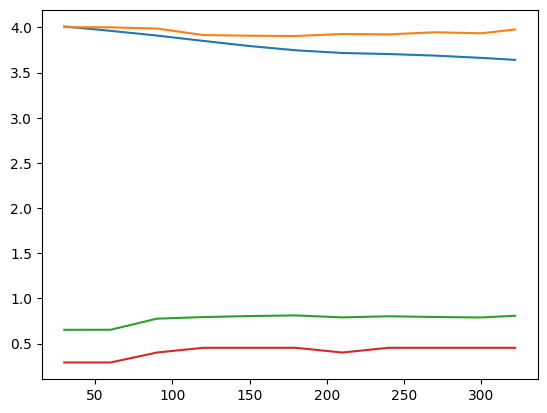

epoch[2/30] iter=30: trainLoss=3.424388, validLoss=3.977094, pol_acc=78.20%, pol_f1=0.4524
epoch[2/30] iter=60: trainLoss=3.439020, validLoss=3.974851, pol_acc=75.90%, pol_f1=0.4020
epoch[2/30] iter=90: trainLoss=3.435223, validLoss=3.939679, pol_acc=77.58%, pol_f1=0.4524
epoch[2/30] iter=120: trainLoss=3.423037, validLoss=3.936351, pol_acc=80.05%, pol_f1=0.4524
epoch[2/30] iter=150: trainLoss=3.400692, validLoss=3.930249, pol_acc=80.14%, pol_f1=0.4524
epoch[2/30] iter=180: trainLoss=3.375139, validLoss=3.926287, pol_acc=80.23%, pol_f1=0.4524
epoch[2/30] iter=210: trainLoss=3.359168, validLoss=3.939655, pol_acc=80.67%, pol_f1=0.4524
epoch[2/30] iter=240: trainLoss=3.361057, validLoss=3.940712, pol_acc=81.99%, pol_f1=0.5253
epoch[2/30] iter=270: trainLoss=3.343447, validLoss=3.924108, pol_acc=82.61%, pol_f1=0.6508
epoch[2/30] iter=300: trainLoss=3.319005, validLoss=3.924386, pol_acc=84.11%, pol_f1=0.5253
epoch[2/30] iter=322: trainLoss=3.297225, validLoss=3.998904, pol_acc=85.44%, pol_f

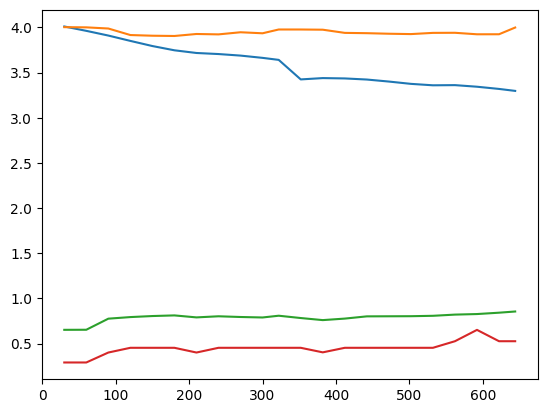

epoch[3/30] iter=30: trainLoss=3.029275, validLoss=3.962859, pol_acc=86.94%, pol_f1=0.5253
epoch[3/30] iter=60: trainLoss=3.014771, validLoss=3.939894, pol_acc=86.94%, pol_f1=0.5253
epoch[3/30] iter=90: trainLoss=2.986376, validLoss=3.910069, pol_acc=90.03%, pol_f1=0.5253
epoch[3/30] iter=120: trainLoss=2.959032, validLoss=4.008654, pol_acc=89.32%, pol_f1=0.5253
epoch[3/30] iter=150: trainLoss=2.923677, validLoss=3.954040, pol_acc=92.32%, pol_f1=0.5253
epoch[3/30] iter=180: trainLoss=2.895461, validLoss=3.974326, pol_acc=92.94%, pol_f1=0.5253
epoch[3/30] iter=210: trainLoss=2.872898, validLoss=4.026409, pol_acc=92.94%, pol_f1=0.5253
epoch[3/30] iter=240: trainLoss=2.860746, validLoss=4.043340, pol_acc=90.03%, pol_f1=0.6508
epoch[3/30] iter=270: trainLoss=2.844245, validLoss=4.097320, pol_acc=88.70%, pol_f1=0.5253
epoch[3/30] iter=300: trainLoss=2.826908, validLoss=4.190172, pol_acc=88.79%, pol_f1=0.6508
epoch[3/30] iter=322: trainLoss=2.806505, validLoss=4.425668, pol_acc=91.53%, pol_f

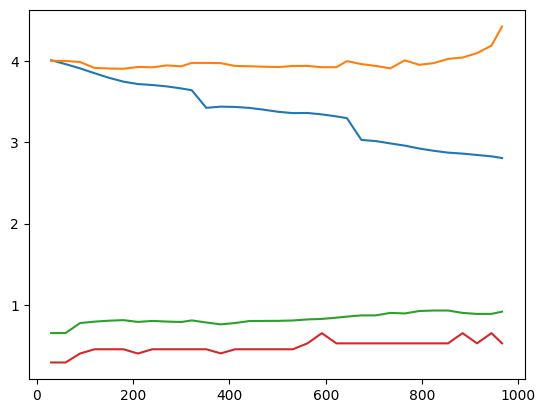

epoch[4/30] iter=30: trainLoss=2.554488, validLoss=4.554623, pol_acc=92.76%, pol_f1=0.6508
epoch[4/30] iter=60: trainLoss=2.673121, validLoss=16.816757, pol_acc=70.17%, pol_f1=0.4412
epoch[4/30] iter=90: trainLoss=2.840582, validLoss=16.235666, pol_acc=91.88%, pol_f1=0.6508
epoch[4/30] iter=120: trainLoss=2.906903, validLoss=12.112555, pol_acc=90.91%, pol_f1=0.6000
epoch[4/30] iter=150: trainLoss=3.040387, validLoss=24.806709, pol_acc=87.64%, pol_f1=0.5380
epoch[4/30] iter=180: trainLoss=3.110994, validLoss=17.743422, pol_acc=92.23%, pol_f1=0.5253
epoch[4/30] iter=210: trainLoss=3.130566, validLoss=11.961692, pol_acc=93.82%, pol_f1=0.6508
epoch[4/30] iter=240: trainLoss=3.141546, validLoss=15.874408, pol_acc=90.38%, pol_f1=0.5253
epoch[4/30] iter=270: trainLoss=3.149271, validLoss=15.104798, pol_acc=91.70%, pol_f1=0.6508
epoch[4/30] iter=300: trainLoss=3.146906, validLoss=17.845438, pol_acc=90.03%, pol_f1=0.6508
epoch[4/30] iter=322: trainLoss=3.137647, validLoss=17.271852, pol_acc=88.

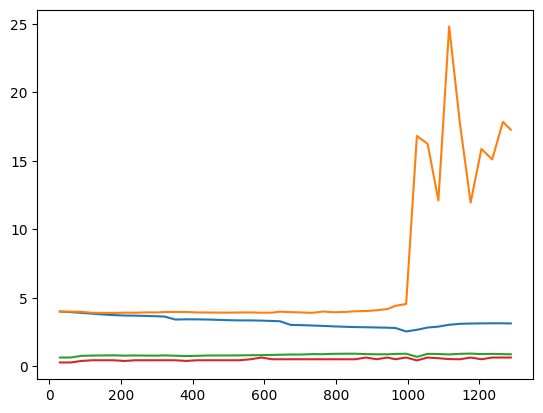

epoch[5/30] iter=30: trainLoss=3.809622, validLoss=15.896507, pol_acc=88.88%, pol_f1=0.6000
epoch[5/30] iter=60: trainLoss=3.716614, validLoss=17.218884, pol_acc=92.06%, pol_f1=0.6508
epoch[5/30] iter=90: trainLoss=3.517003, validLoss=17.275117, pol_acc=93.47%, pol_f1=0.6508
epoch[5/30] iter=120: trainLoss=3.437467, validLoss=20.307185, pol_acc=94.35%, pol_f1=0.6508
epoch[5/30] iter=150: trainLoss=3.361678, validLoss=20.602813, pol_acc=94.53%, pol_f1=0.6508
epoch[5/30] iter=180: trainLoss=3.296969, validLoss=19.954045, pol_acc=94.35%, pol_f1=0.6508
epoch[5/30] iter=210: trainLoss=3.305062, validLoss=21.381754, pol_acc=93.56%, pol_f1=0.6508
epoch[5/30] iter=240: trainLoss=3.308782, validLoss=14.988290, pol_acc=91.88%, pol_f1=0.6508
epoch[5/30] iter=270: trainLoss=3.278793, validLoss=13.289598, pol_acc=84.11%, pol_f1=0.4868
epoch[5/30] iter=300: trainLoss=3.232952, validLoss=12.304740, pol_acc=91.00%, pol_f1=0.6508
epoch[5/30] iter=322: trainLoss=3.200864, validLoss=16.961192, pol_acc=91

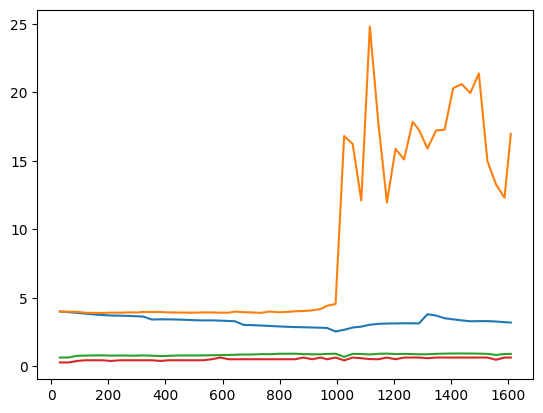

epoch[6/30] iter=30: trainLoss=3.234363, validLoss=16.726012, pol_acc=91.88%, pol_f1=0.6508
epoch[6/30] iter=60: trainLoss=3.302549, validLoss=17.041963, pol_acc=90.73%, pol_f1=0.5667
epoch[6/30] iter=90: trainLoss=3.188951, validLoss=14.919074, pol_acc=91.62%, pol_f1=0.6508
epoch[6/30] iter=120: trainLoss=3.121558, validLoss=17.440173, pol_acc=89.67%, pol_f1=0.5667
epoch[6/30] iter=150: trainLoss=3.071530, validLoss=17.369049, pol_acc=91.00%, pol_f1=0.6508
epoch[6/30] iter=180: trainLoss=2.989672, validLoss=14.469128, pol_acc=91.00%, pol_f1=0.6508
epoch[6/30] iter=210: trainLoss=2.975382, validLoss=10.673599, pol_acc=92.06%, pol_f1=0.6508
epoch[6/30] iter=240: trainLoss=2.952060, validLoss=7.785165, pol_acc=92.14%, pol_f1=0.6508
epoch[6/30] iter=270: trainLoss=2.904624, validLoss=8.772581, pol_acc=93.12%, pol_f1=0.6508
epoch[6/30] iter=300: trainLoss=2.861734, validLoss=6.965202, pol_acc=91.97%, pol_f1=0.6508
epoch[6/30] iter=322: trainLoss=2.834843, validLoss=8.906625, pol_acc=92.23%

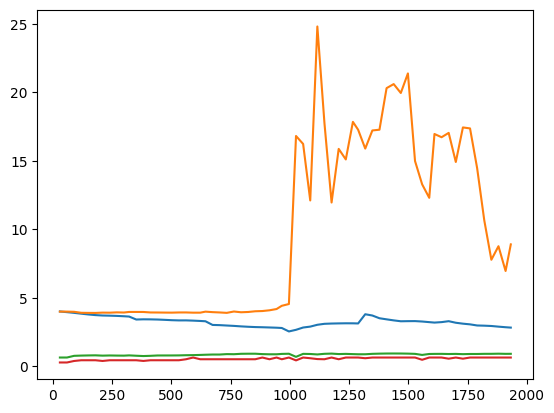

epoch[7/30] iter=30: trainLoss=2.801057, validLoss=15.639464, pol_acc=93.56%, pol_f1=0.6508
epoch[7/30] iter=60: trainLoss=2.790961, validLoss=10.421320, pol_acc=93.29%, pol_f1=0.6508
epoch[7/30] iter=90: trainLoss=2.768107, validLoss=16.771845, pol_acc=93.29%, pol_f1=0.6508
epoch[7/30] iter=120: trainLoss=2.750724, validLoss=14.576832, pol_acc=93.65%, pol_f1=0.6508
epoch[7/30] iter=150: trainLoss=2.715185, validLoss=17.193516, pol_acc=93.73%, pol_f1=0.6508
epoch[7/30] iter=180: trainLoss=2.657041, validLoss=16.296775, pol_acc=94.62%, pol_f1=0.6508
epoch[7/30] iter=210: trainLoss=2.665864, validLoss=13.123870, pol_acc=92.85%, pol_f1=0.5253
epoch[7/30] iter=240: trainLoss=2.642469, validLoss=8.996520, pol_acc=92.85%, pol_f1=0.6508
epoch[7/30] iter=270: trainLoss=2.616981, validLoss=8.184176, pol_acc=93.91%, pol_f1=0.6508
epoch[7/30] iter=300: trainLoss=2.590834, validLoss=16.816687, pol_acc=93.56%, pol_f1=0.6508
epoch[7/30] iter=322: trainLoss=2.578067, validLoss=14.217045, pol_acc=92.8

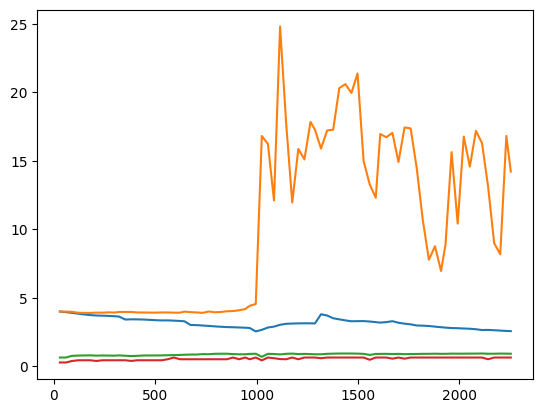

epoch[8/30] iter=30: trainLoss=2.719590, validLoss=9.945398, pol_acc=93.38%, pol_f1=0.6508
epoch[8/30] iter=60: trainLoss=2.723841, validLoss=9.940266, pol_acc=89.67%, pol_f1=0.6508
epoch[8/30] iter=90: trainLoss=2.669907, validLoss=8.426114, pol_acc=93.38%, pol_f1=0.6508
epoch[8/30] iter=120: trainLoss=2.591984, validLoss=7.942288, pol_acc=94.09%, pol_f1=0.6508
epoch[8/30] iter=150: trainLoss=2.548022, validLoss=11.706506, pol_acc=94.00%, pol_f1=0.6508
epoch[8/30] iter=180: trainLoss=2.488099, validLoss=11.779648, pol_acc=94.44%, pol_f1=0.6508
epoch[8/30] iter=210: trainLoss=2.481039, validLoss=10.127916, pol_acc=94.26%, pol_f1=0.6508
epoch[8/30] iter=240: trainLoss=2.462485, validLoss=6.717872, pol_acc=94.09%, pol_f1=0.5253
epoch[8/30] iter=270: trainLoss=2.434691, validLoss=12.562046, pol_acc=94.44%, pol_f1=0.6508
epoch[8/30] iter=300: trainLoss=2.421022, validLoss=12.505537, pol_acc=92.94%, pol_f1=0.5253
epoch[8/30] iter=322: trainLoss=2.423384, validLoss=11.958373, pol_acc=91.88%,

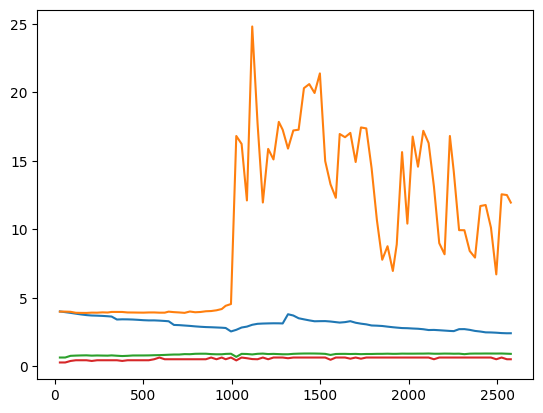

epoch[9/30] iter=30: trainLoss=2.368287, validLoss=11.320066, pol_acc=92.41%, pol_f1=0.5253
epoch[9/30] iter=60: trainLoss=2.385499, validLoss=10.420506, pol_acc=93.12%, pol_f1=0.5253
epoch[9/30] iter=90: trainLoss=2.333270, validLoss=9.105401, pol_acc=93.47%, pol_f1=0.5253
epoch[9/30] iter=120: trainLoss=2.334437, validLoss=10.109887, pol_acc=92.59%, pol_f1=0.5253
epoch[9/30] iter=150: trainLoss=2.312974, validLoss=12.073427, pol_acc=93.65%, pol_f1=0.5253
epoch[9/30] iter=180: trainLoss=2.267564, validLoss=11.859658, pol_acc=93.65%, pol_f1=0.5253
epoch[9/30] iter=210: trainLoss=2.267820, validLoss=13.272098, pol_acc=93.56%, pol_f1=0.5253
epoch[9/30] iter=240: trainLoss=2.271184, validLoss=7.591714, pol_acc=93.56%, pol_f1=0.5253
epoch[9/30] iter=270: trainLoss=2.249040, validLoss=8.220349, pol_acc=94.62%, pol_f1=0.5253
epoch[9/30] iter=300: trainLoss=2.240310, validLoss=12.338134, pol_acc=93.03%, pol_f1=0.5253
epoch[9/30] iter=322: trainLoss=2.229957, validLoss=11.314110, pol_acc=93.65

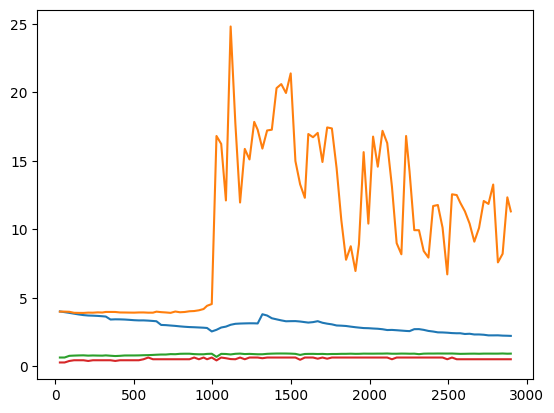

epoch[10/30] iter=30: trainLoss=2.248161, validLoss=11.477607, pol_acc=92.76%, pol_f1=0.5253
epoch[10/30] iter=60: trainLoss=2.267813, validLoss=10.250008, pol_acc=92.50%, pol_f1=0.5253
epoch[10/30] iter=90: trainLoss=2.216375, validLoss=11.166197, pol_acc=93.03%, pol_f1=0.5253
epoch[10/30] iter=120: trainLoss=2.189935, validLoss=11.185682, pol_acc=94.00%, pol_f1=0.5253
epoch[10/30] iter=150: trainLoss=2.176908, validLoss=11.601749, pol_acc=93.56%, pol_f1=0.5253
epoch[10/30] iter=180: trainLoss=2.148668, validLoss=10.884877, pol_acc=93.91%, pol_f1=0.5253
epoch[10/30] iter=210: trainLoss=2.147966, validLoss=14.723216, pol_acc=93.82%, pol_f1=0.5253
epoch[10/30] iter=240: trainLoss=2.149819, validLoss=13.642248, pol_acc=92.23%, pol_f1=0.4524
epoch[10/30] iter=270: trainLoss=2.141254, validLoss=12.780184, pol_acc=93.56%, pol_f1=0.5667
epoch[10/30] iter=300: trainLoss=2.138115, validLoss=12.276674, pol_acc=93.65%, pol_f1=0.6508
epoch[10/30] iter=322: trainLoss=2.131344, validLoss=13.224708,

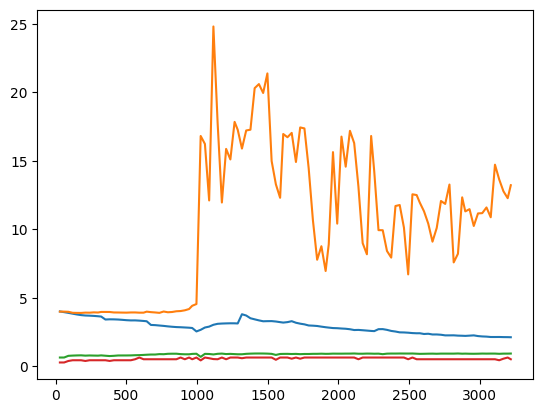

epoch[11/30] iter=30: trainLoss=2.224808, validLoss=13.011463, pol_acc=94.53%, pol_f1=0.6508
epoch[11/30] iter=60: trainLoss=2.249740, validLoss=9.828624, pol_acc=94.35%, pol_f1=0.6508
epoch[11/30] iter=90: trainLoss=2.205232, validLoss=9.901500, pol_acc=93.12%, pol_f1=0.5253
epoch[11/30] iter=120: trainLoss=2.189387, validLoss=12.309683, pol_acc=94.09%, pol_f1=0.5253
epoch[11/30] iter=150: trainLoss=2.183244, validLoss=12.619845, pol_acc=94.35%, pol_f1=0.5253
epoch[11/30] iter=180: trainLoss=2.155359, validLoss=12.933282, pol_acc=94.53%, pol_f1=0.5253
epoch[11/30] iter=210: trainLoss=2.159089, validLoss=12.871904, pol_acc=94.62%, pol_f1=0.4841
epoch[11/30] iter=240: trainLoss=2.156301, validLoss=13.370980, pol_acc=94.00%, pol_f1=0.5253
epoch[11/30] iter=270: trainLoss=2.146042, validLoss=14.919381, pol_acc=94.62%, pol_f1=0.5253
epoch[11/30] iter=300: trainLoss=2.147970, validLoss=11.884874, pol_acc=94.62%, pol_f1=0.6508
epoch[11/30] iter=322: trainLoss=2.139474, validLoss=14.334706, p

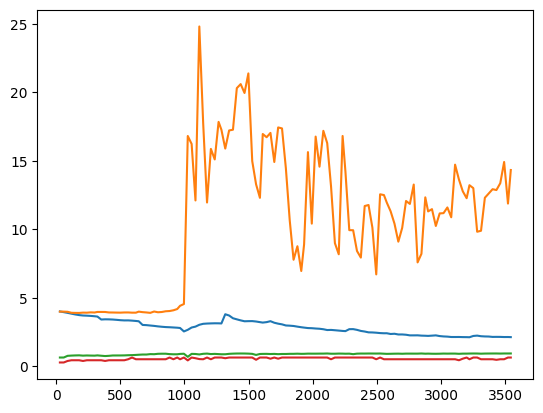

epoch[12/30] iter=30: trainLoss=2.206544, validLoss=13.771720, pol_acc=94.35%, pol_f1=0.6508
epoch[12/30] iter=60: trainLoss=2.234012, validLoss=11.123783, pol_acc=92.32%, pol_f1=0.6000
epoch[12/30] iter=90: trainLoss=2.175197, validLoss=12.297296, pol_acc=93.91%, pol_f1=0.5253
epoch[12/30] iter=120: trainLoss=2.145174, validLoss=11.983244, pol_acc=93.73%, pol_f1=0.4841
epoch[12/30] iter=150: trainLoss=2.133271, validLoss=11.352044, pol_acc=94.79%, pol_f1=0.4841
epoch[12/30] iter=180: trainLoss=2.101991, validLoss=12.820352, pol_acc=94.53%, pol_f1=0.5253
epoch[12/30] iter=210: trainLoss=2.105188, validLoss=12.596752, pol_acc=94.70%, pol_f1=0.5253
epoch[12/30] iter=240: trainLoss=2.095816, validLoss=16.357777, pol_acc=94.53%, pol_f1=0.4841
epoch[12/30] iter=270: trainLoss=2.082170, validLoss=16.242131, pol_acc=94.26%, pol_f1=0.5253
epoch[12/30] iter=300: trainLoss=2.078193, validLoss=14.621698, pol_acc=94.17%, pol_f1=0.5253
epoch[12/30] iter=322: trainLoss=2.072455, validLoss=13.607904,

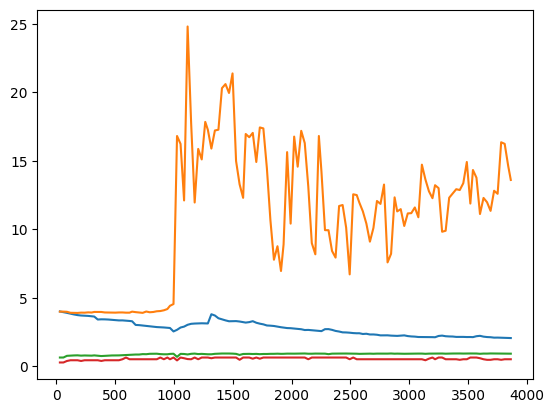

epoch[13/30] iter=30: trainLoss=2.162061, validLoss=14.081438, pol_acc=94.09%, pol_f1=0.5253
epoch[13/30] iter=60: trainLoss=2.183372, validLoss=11.985188, pol_acc=94.44%, pol_f1=0.4841
epoch[13/30] iter=90: trainLoss=2.160470, validLoss=13.760959, pol_acc=93.82%, pol_f1=0.6508
epoch[13/30] iter=120: trainLoss=2.120948, validLoss=11.692496, pol_acc=93.56%, pol_f1=0.6000
epoch[13/30] iter=150: trainLoss=2.100742, validLoss=14.412573, pol_acc=94.88%, pol_f1=0.5253
epoch[13/30] iter=180: trainLoss=2.063930, validLoss=14.167944, pol_acc=94.62%, pol_f1=0.5253
epoch[13/30] iter=210: trainLoss=2.079686, validLoss=11.100391, pol_acc=90.73%, pol_f1=0.5253
epoch[13/30] iter=240: trainLoss=2.070087, validLoss=10.810649, pol_acc=93.91%, pol_f1=0.5253
epoch[13/30] iter=270: trainLoss=2.053679, validLoss=13.071310, pol_acc=93.73%, pol_f1=0.5253
epoch[13/30] iter=300: trainLoss=2.050143, validLoss=11.456035, pol_acc=93.29%, pol_f1=0.5253
epoch[13/30] iter=322: trainLoss=2.037373, validLoss=12.270001,

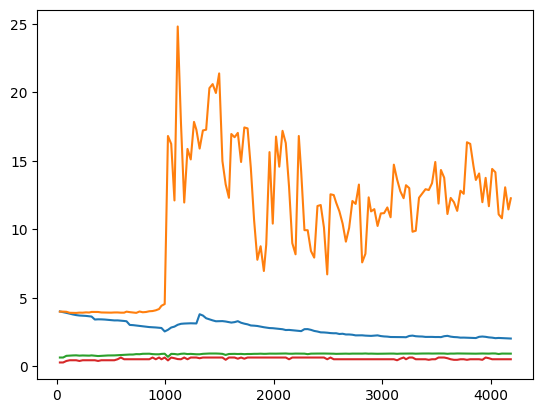

epoch[14/30] iter=30: trainLoss=2.039601, validLoss=11.929722, pol_acc=94.00%, pol_f1=0.5253
epoch[14/30] iter=60: trainLoss=2.071651, validLoss=13.369269, pol_acc=93.56%, pol_f1=1.0000
epoch[14/30] iter=90: trainLoss=2.022601, validLoss=13.817716, pol_acc=93.65%, pol_f1=0.6508
epoch[14/30] iter=120: trainLoss=2.005403, validLoss=15.526849, pol_acc=93.73%, pol_f1=0.5253
epoch[14/30] iter=150: trainLoss=2.004248, validLoss=15.622575, pol_acc=94.17%, pol_f1=0.5253
epoch[14/30] iter=180: trainLoss=1.977627, validLoss=18.484401, pol_acc=94.88%, pol_f1=0.5253
epoch[14/30] iter=210: trainLoss=1.993884, validLoss=14.645455, pol_acc=94.97%, pol_f1=0.5253
epoch[14/30] iter=240: trainLoss=1.992135, validLoss=19.558330, pol_acc=94.09%, pol_f1=0.8000
epoch[14/30] iter=270: trainLoss=1.985006, validLoss=11.077463, pol_acc=95.50%, pol_f1=0.8730
epoch[14/30] iter=300: trainLoss=1.981401, validLoss=11.547051, pol_acc=95.23%, pol_f1=0.5253
epoch[14/30] iter=322: trainLoss=1.975470, validLoss=14.529192,

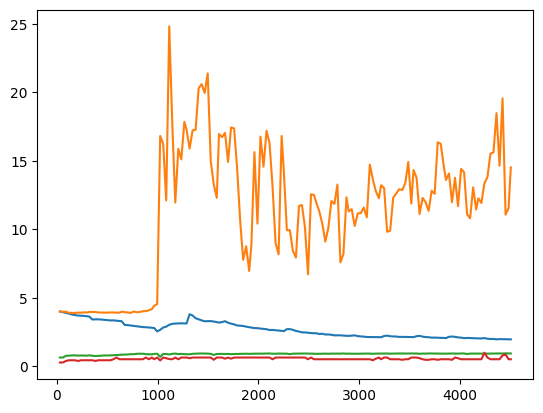

epoch[15/30] iter=30: trainLoss=2.097829, validLoss=15.321955, pol_acc=93.29%, pol_f1=1.0000
epoch[15/30] iter=60: trainLoss=2.125041, validLoss=13.712359, pol_acc=94.70%, pol_f1=0.6508
epoch[15/30] iter=90: trainLoss=2.053502, validLoss=13.456699, pol_acc=94.44%, pol_f1=0.5253
epoch[15/30] iter=120: trainLoss=2.017605, validLoss=15.426877, pol_acc=94.79%, pol_f1=0.6508
epoch[15/30] iter=150: trainLoss=2.004545, validLoss=14.704613, pol_acc=94.70%, pol_f1=0.6508
epoch[15/30] iter=180: trainLoss=1.970276, validLoss=16.173278, pol_acc=93.91%, pol_f1=0.5253
epoch[15/30] iter=210: trainLoss=1.976414, validLoss=15.885309, pol_acc=94.62%, pol_f1=0.5253
epoch[15/30] iter=240: trainLoss=1.967571, validLoss=17.587127, pol_acc=94.53%, pol_f1=0.5253
epoch[15/30] iter=270: trainLoss=1.959944, validLoss=16.004495, pol_acc=94.97%, pol_f1=0.8730
epoch[15/30] iter=300: trainLoss=1.957208, validLoss=15.243081, pol_acc=94.53%, pol_f1=0.8730
epoch[15/30] iter=322: trainLoss=1.948547, validLoss=16.677285,

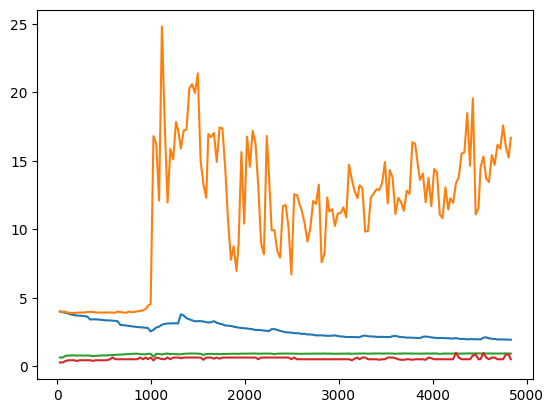

epoch[16/30] iter=30: trainLoss=2.059315, validLoss=16.227178, pol_acc=95.06%, pol_f1=0.8730
epoch[16/30] iter=60: trainLoss=2.088708, validLoss=17.109334, pol_acc=94.26%, pol_f1=0.8730
epoch[16/30] iter=90: trainLoss=2.036061, validLoss=16.017710, pol_acc=94.53%, pol_f1=0.5253
epoch[16/30] iter=120: trainLoss=2.010787, validLoss=19.201195, pol_acc=94.62%, pol_f1=0.8730
epoch[16/30] iter=150: trainLoss=1.997691, validLoss=15.903830, pol_acc=94.09%, pol_f1=0.4524
epoch[16/30] iter=180: trainLoss=1.960364, validLoss=23.965508, pol_acc=94.53%, pol_f1=0.5253
epoch[16/30] iter=210: trainLoss=1.967987, validLoss=20.960475, pol_acc=94.09%, pol_f1=0.8000
epoch[16/30] iter=240: trainLoss=1.962547, validLoss=14.781849, pol_acc=95.06%, pol_f1=0.5253
epoch[16/30] iter=270: trainLoss=1.953299, validLoss=16.714664, pol_acc=94.88%, pol_f1=0.5253
epoch[16/30] iter=300: trainLoss=1.947340, validLoss=17.082423, pol_acc=95.32%, pol_f1=0.8000
epoch[16/30] iter=322: trainLoss=1.939791, validLoss=18.713905,

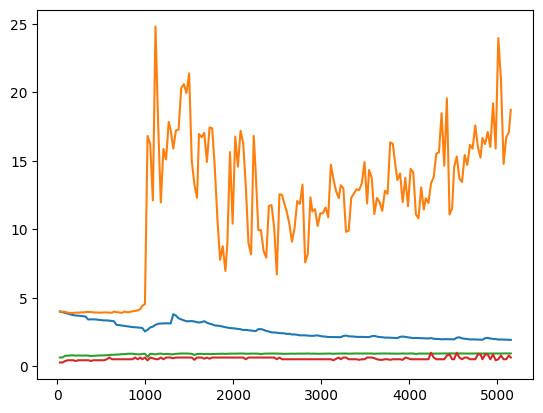

epoch[17/30] iter=30: trainLoss=2.037179, validLoss=17.647050, pol_acc=94.09%, pol_f1=0.5253
epoch[17/30] iter=60: trainLoss=2.049596, validLoss=16.731609, pol_acc=94.70%, pol_f1=1.0000
epoch[17/30] iter=90: trainLoss=1.986980, validLoss=15.378986, pol_acc=94.35%, pol_f1=0.6508
epoch[17/30] iter=120: trainLoss=1.956757, validLoss=14.834257, pol_acc=94.62%, pol_f1=1.0000
epoch[17/30] iter=150: trainLoss=1.944519, validLoss=14.884708, pol_acc=93.47%, pol_f1=0.7778
epoch[17/30] iter=180: trainLoss=1.910543, validLoss=16.998059, pol_acc=95.06%, pol_f1=1.0000
epoch[17/30] iter=210: trainLoss=1.917438, validLoss=15.996195, pol_acc=94.88%, pol_f1=1.0000
epoch[17/30] iter=240: trainLoss=1.913775, validLoss=20.762206, pol_acc=94.44%, pol_f1=0.8730
epoch[17/30] iter=270: trainLoss=1.907535, validLoss=18.064975, pol_acc=94.09%, pol_f1=0.8730
epoch[17/30] iter=300: trainLoss=1.902338, validLoss=18.624945, pol_acc=93.65%, pol_f1=0.8730
epoch[17/30] iter=322: trainLoss=1.896707, validLoss=16.434203,

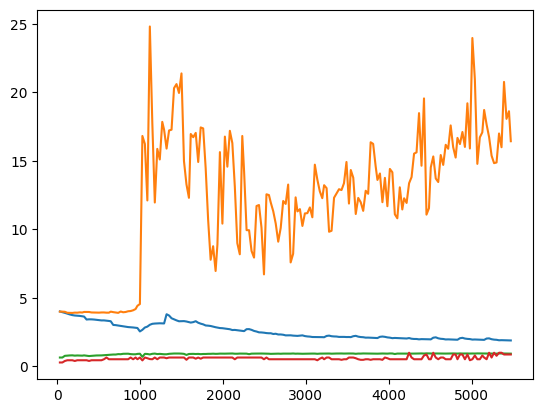

epoch[18/30] iter=30: trainLoss=1.940478, validLoss=18.504579, pol_acc=94.09%, pol_f1=0.8730
epoch[18/30] iter=60: trainLoss=1.984053, validLoss=19.686870, pol_acc=94.35%, pol_f1=1.0000
epoch[18/30] iter=90: trainLoss=1.931737, validLoss=20.021737, pol_acc=94.70%, pol_f1=1.0000
epoch[18/30] iter=120: trainLoss=1.914396, validLoss=19.923823, pol_acc=94.44%, pol_f1=1.0000
epoch[18/30] iter=150: trainLoss=1.908265, validLoss=20.809992, pol_acc=94.00%, pol_f1=1.0000
epoch[18/30] iter=180: trainLoss=1.875595, validLoss=25.234455, pol_acc=94.53%, pol_f1=0.9158
epoch[18/30] iter=210: trainLoss=1.885423, validLoss=21.947949, pol_acc=86.58%, pol_f1=0.8519
epoch[18/30] iter=240: trainLoss=1.877773, validLoss=19.402556, pol_acc=94.53%, pol_f1=1.0000
epoch[18/30] iter=270: trainLoss=1.865943, validLoss=20.713409, pol_acc=94.26%, pol_f1=1.0000
epoch[18/30] iter=300: trainLoss=1.863228, validLoss=18.789348, pol_acc=94.70%, pol_f1=1.0000
epoch[18/30] iter=322: trainLoss=1.856454, validLoss=18.939355,

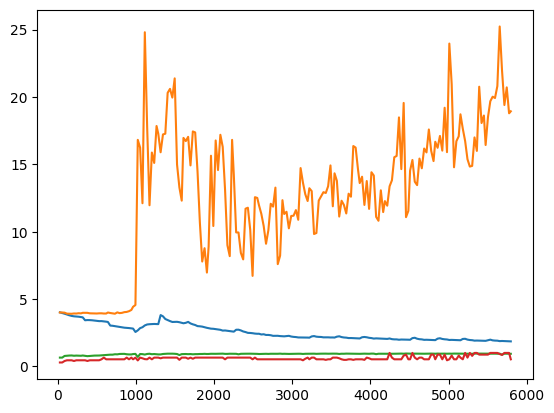

epoch[19/30] iter=30: trainLoss=1.929829, validLoss=20.009118, pol_acc=92.59%, pol_f1=0.8730
epoch[19/30] iter=60: trainLoss=1.940554, validLoss=21.422924, pol_acc=93.47%, pol_f1=0.7778
epoch[19/30] iter=90: trainLoss=1.903050, validLoss=20.269823, pol_acc=94.35%, pol_f1=1.0000
epoch[19/30] iter=120: trainLoss=1.883586, validLoss=17.498747, pol_acc=94.53%, pol_f1=0.8730
epoch[19/30] iter=150: trainLoss=1.885596, validLoss=16.454387, pol_acc=94.44%, pol_f1=0.8730
epoch[19/30] iter=180: trainLoss=1.852007, validLoss=16.745863, pol_acc=94.53%, pol_f1=0.8730
epoch[19/30] iter=210: trainLoss=1.857582, validLoss=17.390781, pol_acc=94.00%, pol_f1=0.8730
epoch[19/30] iter=240: trainLoss=1.859226, validLoss=13.730624, pol_acc=92.23%, pol_f1=0.8730
epoch[19/30] iter=270: trainLoss=1.851526, validLoss=15.049669, pol_acc=92.94%, pol_f1=0.8730
epoch[19/30] iter=300: trainLoss=1.849824, validLoss=15.205691, pol_acc=94.62%, pol_f1=0.8730
epoch[19/30] iter=322: trainLoss=1.843927, validLoss=15.797423,

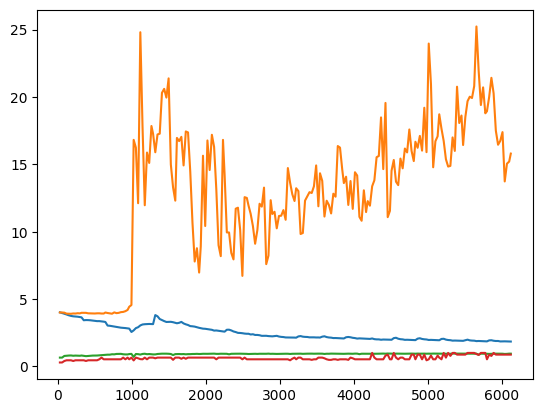

epoch[20/30] iter=30: trainLoss=1.882956, validLoss=16.806285, pol_acc=94.35%, pol_f1=0.8730
epoch[20/30] iter=60: trainLoss=1.936382, validLoss=16.638912, pol_acc=92.59%, pol_f1=0.5253
epoch[20/30] iter=90: trainLoss=1.897365, validLoss=15.643094, pol_acc=93.65%, pol_f1=0.8730
epoch[20/30] iter=120: trainLoss=1.875275, validLoss=17.063026, pol_acc=93.91%, pol_f1=0.8730
epoch[20/30] iter=150: trainLoss=1.866562, validLoss=17.095783, pol_acc=93.82%, pol_f1=0.8730
epoch[20/30] iter=180: trainLoss=1.838785, validLoss=16.527850, pol_acc=93.82%, pol_f1=0.8730
epoch[20/30] iter=210: trainLoss=1.845059, validLoss=24.788088, pol_acc=93.38%, pol_f1=0.8730
epoch[20/30] iter=240: trainLoss=1.848275, validLoss=21.750942, pol_acc=87.82%, pol_f1=0.8730
epoch[20/30] iter=270: trainLoss=1.841270, validLoss=21.247261, pol_acc=91.53%, pol_f1=0.8730
epoch[20/30] iter=300: trainLoss=1.836589, validLoss=27.074663, pol_acc=91.79%, pol_f1=0.8730
epoch[20/30] iter=322: trainLoss=1.830177, validLoss=24.687402,

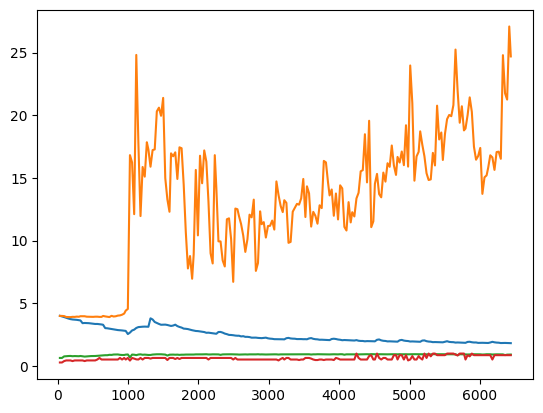

epoch[21/30] iter=30: trainLoss=1.944738, validLoss=22.283983, pol_acc=90.82%, pol_f1=0.8730
epoch[21/30] iter=60: trainLoss=1.939099, validLoss=19.725686, pol_acc=92.14%, pol_f1=0.8730
epoch[21/30] iter=90: trainLoss=1.868764, validLoss=19.134270, pol_acc=93.29%, pol_f1=0.8730
epoch[21/30] iter=120: trainLoss=1.831439, validLoss=19.424269, pol_acc=93.20%, pol_f1=0.8730
epoch[21/30] iter=150: trainLoss=1.818696, validLoss=19.958968, pol_acc=92.85%, pol_f1=0.8730
epoch[21/30] iter=180: trainLoss=1.786281, validLoss=19.144051, pol_acc=93.12%, pol_f1=0.8730
epoch[21/30] iter=210: trainLoss=1.791058, validLoss=19.232844, pol_acc=93.12%, pol_f1=0.8730
epoch[21/30] iter=240: trainLoss=1.792699, validLoss=16.968256, pol_acc=92.59%, pol_f1=0.5253
epoch[21/30] iter=270: trainLoss=1.786553, validLoss=19.600672, pol_acc=92.85%, pol_f1=0.8730
epoch[21/30] iter=300: trainLoss=1.790533, validLoss=19.337797, pol_acc=92.14%, pol_f1=0.8730
epoch[21/30] iter=322: trainLoss=1.784366, validLoss=25.352570,

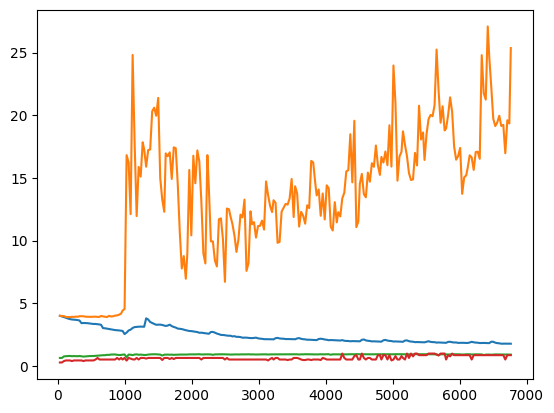

epoch[22/30] iter=30: trainLoss=1.853502, validLoss=25.558520, pol_acc=90.29%, pol_f1=0.8730
epoch[22/30] iter=60: trainLoss=1.909307, validLoss=22.833584, pol_acc=91.26%, pol_f1=0.8730
epoch[22/30] iter=90: trainLoss=1.867483, validLoss=23.201336, pol_acc=92.32%, pol_f1=0.8730
epoch[22/30] iter=120: trainLoss=1.843542, validLoss=23.851894, pol_acc=92.50%, pol_f1=0.8730
epoch[22/30] iter=150: trainLoss=1.834026, validLoss=24.652194, pol_acc=92.50%, pol_f1=0.8730
epoch[22/30] iter=180: trainLoss=1.799606, validLoss=24.291092, pol_acc=92.67%, pol_f1=0.8730
epoch[22/30] iter=210: trainLoss=1.807737, validLoss=23.977489, pol_acc=86.67%, pol_f1=0.8730
epoch[22/30] iter=240: trainLoss=1.811000, validLoss=21.812923, pol_acc=92.50%, pol_f1=0.8730
epoch[22/30] iter=270: trainLoss=1.802926, validLoss=22.531717, pol_acc=91.70%, pol_f1=0.8730
epoch[22/30] iter=300: trainLoss=1.801716, validLoss=23.000808, pol_acc=92.59%, pol_f1=0.8730
epoch[22/30] iter=322: trainLoss=1.797903, validLoss=22.966687,

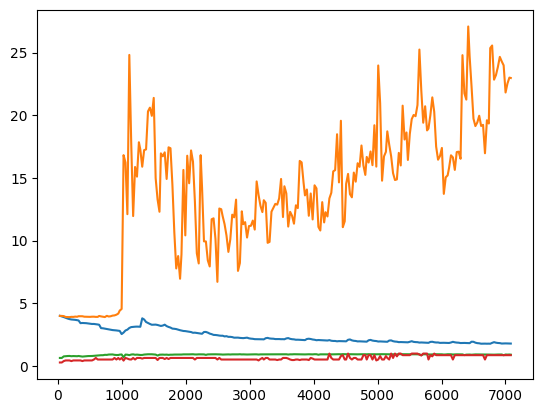

epoch[23/30] iter=30: trainLoss=1.804632, validLoss=23.328136, pol_acc=93.56%, pol_f1=0.8730
epoch[23/30] iter=60: trainLoss=1.839680, validLoss=23.972489, pol_acc=93.12%, pol_f1=0.8730
epoch[23/30] iter=90: trainLoss=1.797941, validLoss=21.954134, pol_acc=94.17%, pol_f1=0.8730
epoch[23/30] iter=120: trainLoss=1.789457, validLoss=22.688779, pol_acc=93.47%, pol_f1=0.8730
epoch[23/30] iter=150: trainLoss=1.782837, validLoss=24.598462, pol_acc=92.41%, pol_f1=0.7778
epoch[23/30] iter=180: trainLoss=1.754446, validLoss=24.886129, pol_acc=92.67%, pol_f1=0.7778
epoch[23/30] iter=210: trainLoss=1.762942, validLoss=22.990012, pol_acc=93.38%, pol_f1=0.8730
epoch[23/30] iter=240: trainLoss=1.764072, validLoss=23.225057, pol_acc=91.97%, pol_f1=0.7778
epoch[23/30] iter=270: trainLoss=1.759429, validLoss=21.965270, pol_acc=93.03%, pol_f1=0.7778
epoch[23/30] iter=300: trainLoss=1.762666, validLoss=23.236125, pol_acc=93.12%, pol_f1=0.8730
epoch[23/30] iter=322: trainLoss=1.757814, validLoss=22.738716,

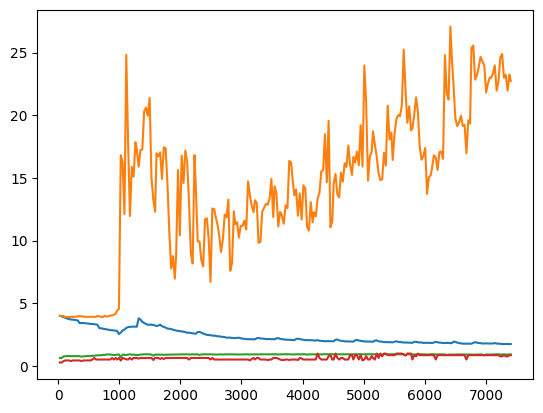

epoch[24/30] iter=30: trainLoss=1.881365, validLoss=21.350067, pol_acc=93.20%, pol_f1=0.8730
epoch[24/30] iter=60: trainLoss=1.894124, validLoss=21.182805, pol_acc=94.09%, pol_f1=0.8730
epoch[24/30] iter=90: trainLoss=1.849471, validLoss=21.298427, pol_acc=93.73%, pol_f1=0.8730
epoch[24/30] iter=120: trainLoss=1.832418, validLoss=22.883489, pol_acc=93.91%, pol_f1=0.8730
epoch[24/30] iter=150: trainLoss=1.831537, validLoss=23.904017, pol_acc=93.91%, pol_f1=0.8730
epoch[24/30] iter=180: trainLoss=1.796932, validLoss=24.842881, pol_acc=93.82%, pol_f1=0.8730
epoch[24/30] iter=210: trainLoss=1.805785, validLoss=25.713601, pol_acc=92.23%, pol_f1=0.8000
epoch[24/30] iter=240: trainLoss=1.798426, validLoss=24.223008, pol_acc=93.56%, pol_f1=0.8730
epoch[24/30] iter=270: trainLoss=1.791170, validLoss=23.318832, pol_acc=94.00%, pol_f1=0.8730
epoch[24/30] iter=300: trainLoss=1.800114, validLoss=24.277651, pol_acc=93.29%, pol_f1=0.8730
epoch[24/30] iter=322: trainLoss=1.789663, validLoss=24.996214,

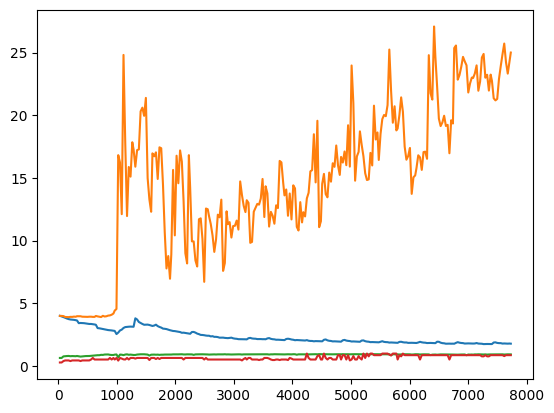

epoch[25/30] iter=30: trainLoss=1.791829, validLoss=24.364563, pol_acc=92.85%, pol_f1=0.8730
epoch[25/30] iter=60: trainLoss=1.884753, validLoss=23.371092, pol_acc=89.67%, pol_f1=0.7047
epoch[25/30] iter=90: trainLoss=1.819977, validLoss=24.190245, pol_acc=93.03%, pol_f1=0.9158
epoch[25/30] iter=120: trainLoss=1.805734, validLoss=24.636490, pol_acc=83.50%, pol_f1=0.9158
epoch[25/30] iter=150: trainLoss=1.807511, validLoss=24.297634, pol_acc=91.70%, pol_f1=0.7047
epoch[25/30] iter=180: trainLoss=1.768835, validLoss=25.811081, pol_acc=93.47%, pol_f1=1.0000
epoch[25/30] iter=210: trainLoss=1.771975, validLoss=24.961631, pol_acc=93.20%, pol_f1=0.7778
epoch[25/30] iter=240: trainLoss=1.768767, validLoss=24.604703, pol_acc=93.47%, pol_f1=1.0000
epoch[25/30] iter=270: trainLoss=1.760491, validLoss=23.007409, pol_acc=92.76%, pol_f1=0.7047
epoch[25/30] iter=300: trainLoss=1.757687, validLoss=23.362124, pol_acc=94.35%, pol_f1=0.8730
epoch[25/30] iter=322: trainLoss=1.748657, validLoss=24.519875,

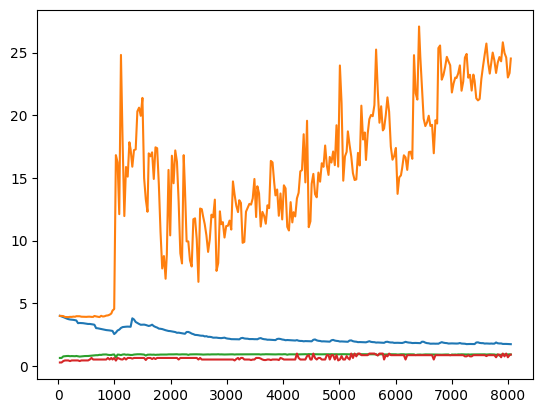

epoch[26/30] iter=30: trainLoss=1.778335, validLoss=21.147583, pol_acc=93.47%, pol_f1=0.8730
epoch[26/30] iter=60: trainLoss=1.807236, validLoss=20.831246, pol_acc=92.50%, pol_f1=0.8730
epoch[26/30] iter=90: trainLoss=1.769824, validLoss=23.354094, pol_acc=93.82%, pol_f1=0.8730
epoch[26/30] iter=120: trainLoss=1.756527, validLoss=23.873360, pol_acc=94.26%, pol_f1=0.8730
epoch[26/30] iter=150: trainLoss=1.748948, validLoss=24.587542, pol_acc=94.70%, pol_f1=0.8730
epoch[26/30] iter=180: trainLoss=1.720606, validLoss=23.818325, pol_acc=93.82%, pol_f1=0.8730
epoch[26/30] iter=210: trainLoss=1.731251, validLoss=23.919490, pol_acc=93.91%, pol_f1=0.8730
epoch[26/30] iter=240: trainLoss=1.737001, validLoss=25.814990, pol_acc=94.70%, pol_f1=0.8730
epoch[26/30] iter=270: trainLoss=1.739250, validLoss=22.560742, pol_acc=94.53%, pol_f1=0.8730
epoch[26/30] iter=300: trainLoss=1.744234, validLoss=21.796036, pol_acc=94.44%, pol_f1=0.8730
epoch[26/30] iter=322: trainLoss=1.740115, validLoss=26.186908,

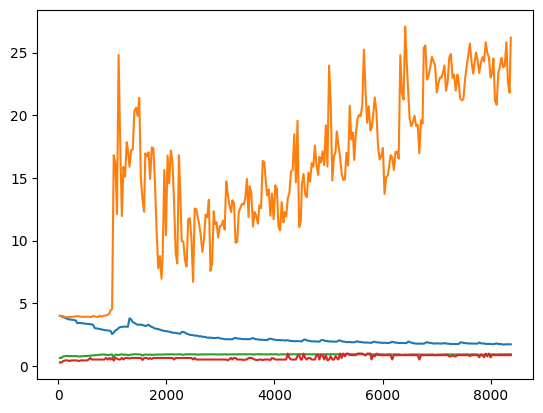

epoch[27/30] iter=30: trainLoss=1.829204, validLoss=23.565531, pol_acc=94.44%, pol_f1=0.8730
epoch[27/30] iter=60: trainLoss=1.863926, validLoss=20.469623, pol_acc=93.56%, pol_f1=0.8730
epoch[27/30] iter=90: trainLoss=1.821986, validLoss=22.839417, pol_acc=94.70%, pol_f1=0.8730
epoch[27/30] iter=120: trainLoss=1.800631, validLoss=22.978377, pol_acc=95.23%, pol_f1=0.8730
epoch[27/30] iter=150: trainLoss=1.787347, validLoss=24.044287, pol_acc=94.62%, pol_f1=0.8730
epoch[27/30] iter=180: trainLoss=1.758728, validLoss=24.857792, pol_acc=94.88%, pol_f1=0.8730
epoch[27/30] iter=210: trainLoss=1.765203, validLoss=24.917873, pol_acc=93.91%, pol_f1=0.8730
epoch[27/30] iter=240: trainLoss=1.765329, validLoss=25.837569, pol_acc=93.82%, pol_f1=0.8730
epoch[27/30] iter=270: trainLoss=1.756158, validLoss=25.180387, pol_acc=93.56%, pol_f1=0.8730
epoch[27/30] iter=300: trainLoss=1.756259, validLoss=25.326939, pol_acc=94.44%, pol_f1=0.8730
epoch[27/30] iter=322: trainLoss=1.749698, validLoss=26.166153,

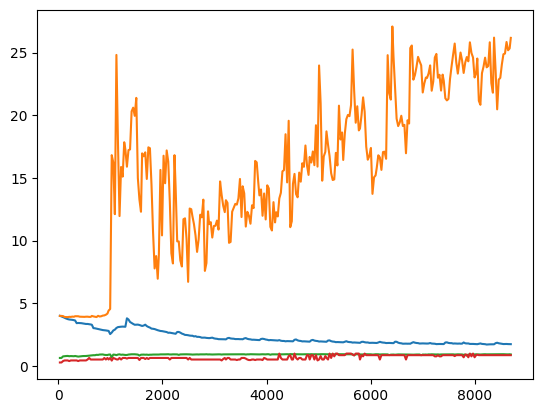

epoch[28/30] iter=30: trainLoss=1.836285, validLoss=22.598135, pol_acc=92.76%, pol_f1=0.8730
epoch[28/30] iter=60: trainLoss=1.837441, validLoss=27.397767, pol_acc=92.41%, pol_f1=0.8730
epoch[28/30] iter=90: trainLoss=1.793032, validLoss=26.161231, pol_acc=93.38%, pol_f1=0.8730
epoch[28/30] iter=120: trainLoss=1.788220, validLoss=29.111229, pol_acc=93.03%, pol_f1=0.8730
epoch[28/30] iter=150: trainLoss=1.774903, validLoss=28.627853, pol_acc=92.41%, pol_f1=0.8730
epoch[28/30] iter=180: trainLoss=1.746262, validLoss=27.852441, pol_acc=93.38%, pol_f1=0.8730
epoch[28/30] iter=210: trainLoss=1.755809, validLoss=25.049672, pol_acc=94.17%, pol_f1=0.8730
epoch[28/30] iter=240: trainLoss=1.757598, validLoss=21.510985, pol_acc=92.50%, pol_f1=0.8730
epoch[28/30] iter=270: trainLoss=1.753812, validLoss=22.458555, pol_acc=93.73%, pol_f1=0.8730
epoch[28/30] iter=300: trainLoss=1.756942, validLoss=21.221547, pol_acc=92.76%, pol_f1=0.8730
epoch[28/30] iter=322: trainLoss=1.749782, validLoss=22.521448,

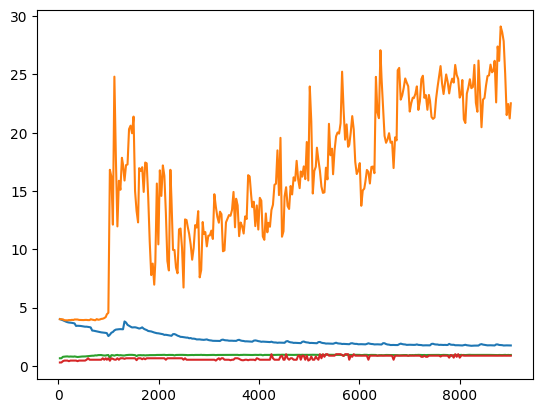

epoch[29/30] iter=30: trainLoss=1.810469, validLoss=18.303548, pol_acc=93.47%, pol_f1=0.8730
epoch[29/30] iter=60: trainLoss=1.804330, validLoss=18.689759, pol_acc=92.94%, pol_f1=0.8730
epoch[29/30] iter=90: trainLoss=1.772889, validLoss=21.840035, pol_acc=93.56%, pol_f1=0.8730
epoch[29/30] iter=120: trainLoss=1.761458, validLoss=22.166358, pol_acc=93.38%, pol_f1=0.8730
epoch[29/30] iter=150: trainLoss=1.760718, validLoss=25.210061, pol_acc=92.59%, pol_f1=0.8730
epoch[29/30] iter=180: trainLoss=1.736722, validLoss=24.678935, pol_acc=93.47%, pol_f1=0.8730
epoch[29/30] iter=210: trainLoss=1.745243, validLoss=23.453927, pol_acc=92.67%, pol_f1=0.8730
epoch[29/30] iter=240: trainLoss=1.744743, validLoss=25.318589, pol_acc=93.03%, pol_f1=0.8730
epoch[29/30] iter=270: trainLoss=1.740909, validLoss=24.240652, pol_acc=92.23%, pol_f1=0.8730
epoch[29/30] iter=300: trainLoss=1.743497, validLoss=22.537960, pol_acc=92.67%, pol_f1=0.8730
epoch[29/30] iter=322: trainLoss=1.737104, validLoss=25.539436,

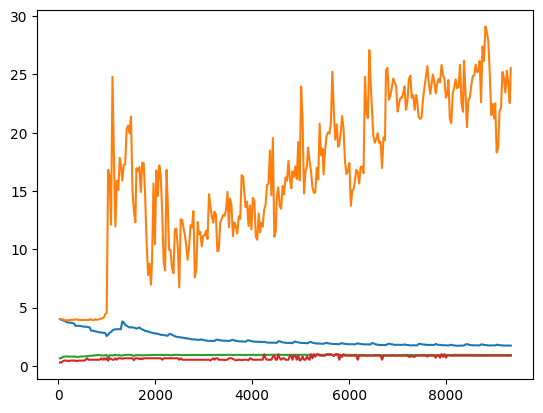

epoch[30/30] iter=30: trainLoss=1.757941, validLoss=18.355704, pol_acc=92.94%, pol_f1=0.8730
epoch[30/30] iter=60: trainLoss=1.784659, validLoss=18.674970, pol_acc=93.38%, pol_f1=0.8730
epoch[30/30] iter=90: trainLoss=1.750690, validLoss=20.350790, pol_acc=93.73%, pol_f1=0.8730
epoch[30/30] iter=120: trainLoss=1.747810, validLoss=21.419308, pol_acc=93.65%, pol_f1=0.8730
epoch[30/30] iter=150: trainLoss=1.746824, validLoss=24.613822, pol_acc=93.91%, pol_f1=0.8730
epoch[30/30] iter=180: trainLoss=1.723677, validLoss=24.805123, pol_acc=93.56%, pol_f1=0.8730
epoch[30/30] iter=210: trainLoss=1.734544, validLoss=24.801944, pol_acc=93.82%, pol_f1=0.8730
epoch[30/30] iter=240: trainLoss=1.738692, validLoss=28.794079, pol_acc=94.17%, pol_f1=0.8730
epoch[30/30] iter=270: trainLoss=1.738340, validLoss=25.628846, pol_acc=93.12%, pol_f1=0.8730
epoch[30/30] iter=300: trainLoss=1.749484, validLoss=24.200399, pol_acc=94.00%, pol_f1=1.0000
epoch[30/30] iter=322: trainLoss=1.742816, validLoss=24.724007,

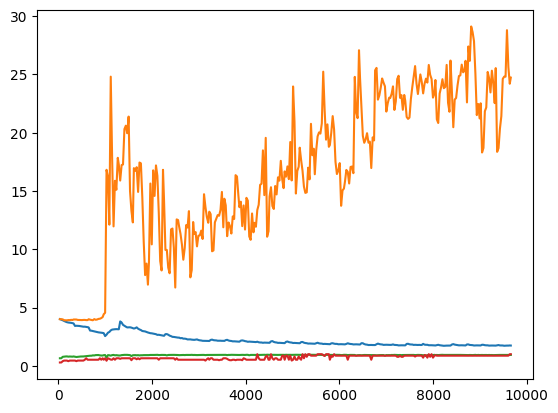

In [ ]:
#学習本体
model.train()
for epoch in range(num_epoch):  # num_epoch分繰り返す
    train_loss = 0
    for iter, (target, sentence, category_labels, pol_labels) in enumerate(train_dataloader, 1):
        category_labels = category_labels.to(device) #カテゴリーラベルをデバイスに移動
        pol_labels = pol_labels.to(device)  # 極性ラベルをデバイスに移動
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        optimizer.zero_grad()
        pred = model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        category_loss = loss_fct(pred["category_logits"], category_labels)
        loss = pol_loss + category_loss # 2つの損失を合計（必要に応じて重み付けも可能）
        train_loss += loss.item()
        loss.backward()  # 誤差伝播
        optimizer.step()  # パラメータ更新

        if iter % 30 == 0:  # 一定回数ごとに未知データに対する分類精度を調べる
            train_losslist.append(train_loss/iter)
            reportProgress(model, val_dataloader, category_labels, pol_labels)

    # epochの最後
    train_losslist.append(train_loss/iter)
    reportProgress(model, val_dataloader, category_labels, pol_labels)
    torch.save(model.state_dict(), f'/content/drive/MyDrive/修士研究/共有用/実験1/model_param/GRL+multi/model_epoch_{epoch+1}.pth')

    # グラフ化
    plt.plot(iterlist, train_losslist)
    plt.plot(iterlist, val_losslist)
    plt.plot(iterlist, pol_acclist)
    plt.plot(iterlist, pol_f1list)
    plt.show()

## テスト

In [ ]:
#保存された状態辞書のロード
model_path = "/content/drive/MyDrive/修士研究/共有用/実験1/model_param/GRL+multi/model_epoch_26.pth"


model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [ ]:
#テストデータでの検証

model.eval()  # モデルを評価モードに変更
total_loss, pol_total_correct, category_total_correct, total_samples = 0, 0, 0, len(test_dataset)
pol_predictions, pol_labels_list, category_predictions, category_labels_list = [], [], [], []

pooler_output = []

# 誤った予測とその詳細を記録するリスト
incorrect_polarity_samples = []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, category_labels, pol_labels) in enumerate(test_dataloader):
        category_labels = category_labels.to(device)
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        category_loss = loss_fct(pred["category_logits"], category_labels)
        loss = pol_loss + category_loss
        total_loss += loss.item()

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        pred_category_labels = pred["category_logits"].argmax(dim=1)
        category_total_correct += (pred_category_labels == category_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())
        category_predictions.extend(pred_category_labels.cpu().numpy())
        category_labels_list.extend(category_labels.cpu().numpy())


        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })


avg_loss = total_loss / len(test_dataloader)
pol_accuracy = pol_total_correct / total_samples
category_accuracy = category_total_correct / total_samples

# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')
category_f1 = f1_score(category_labels_list, category_predictions, average='macro')

# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)
category_report = classification_report(category_labels_list, category_predictions)

# 結果の出力
print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
#print(f"Test Category Accuracy: {category_accuracy:.4f}, F1: {category_f1:.4f}")
print("Pol Classification Report:\n", pol_report)
#print("Category Classification Report:\n", category_report)

Test Loss: 28.1303
Test Pol Accuracy: 0.9329, F1: 0.8343
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       323
           1       0.60      0.67      0.63         9
           2       0.95      0.90      0.92       234

    accuracy                           0.93       566
   macro avg       0.83      0.84      0.83       566
weighted avg       0.93      0.93      0.93       566



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

In [ ]:
#検証データでの検証

model.eval()  # モデルを評価モードに変更
total_loss, pol_total_correct, category_total_correct, total_samples = 0, 0, 0, len(val_dataset)
pol_predictions, pol_labels_list, category_predictions, category_labels_list = [], [], [], []

pooler_output = []

# 誤った予測とその詳細を記録するリスト
incorrect_polarity_samples = []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, category_labels, pol_labels) in enumerate(val_dataloader):
        category_labels = category_labels.to(device)
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        category_loss = loss_fct(pred["category_logits"], category_labels)
        loss = pol_loss + category_loss
        total_loss += loss.item()

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        pred_category_labels = pred["category_logits"].argmax(dim=1)
        category_total_correct += (pred_category_labels == category_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())
        category_predictions.extend(pred_category_labels.cpu().numpy())
        category_labels_list.extend(category_labels.cpu().numpy())


        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })


avg_loss = total_loss / len(val_dataloader)
pol_accuracy = pol_total_correct / total_samples
category_accuracy = category_total_correct / total_samples

# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')
category_f1 = f1_score(category_labels_list, category_predictions, average='macro')

# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)
category_report = classification_report(category_labels_list, category_predictions)

# 結果の出力
print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
#print(f"Test Category Accuracy: {category_accuracy:.4f}, F1: {category_f1:.4f}")
print("Pol Classification Report:\n", pol_report)
#print("Category Classification Report:\n", category_report)

Test Loss: 26.1869
Test Pol Accuracy: 0.9479, F1: 0.8001
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       739
           1       0.56      0.45      0.50        20
           2       0.93      0.94      0.93       374

    accuracy                           0.95      1133
   macro avg       0.82      0.78      0.80      1133
weighted avg       0.95      0.95      0.95      1133



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

## t-SNEによる可視化

In [ ]:
#学習データをモデルに通してpooler_outputベクトルを得る

model.eval()  # モデルを評価モードに変更

pooler_output = []
pol_labels_list = []
category_labels_list = []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for target, sentence, category_labels, pol_labels in train_dataloader:
        category_labels = category_labels.to(device)
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = model(**input)
        pooler_output.append(pred["pooler_output"])
        pol_labels_list.append(pol_labels)
        category_labels_list.append(category_labels)

In [ ]:
# pooler_outputを適切な形に整形
pooler_output = torch.cat(pooler_output, dim=0)  # バッチの次元で結合
pooler_output_np = pooler_output.cpu().numpy()  # numpy形式に変換

In [ ]:
# t-SNEで低次元に変換
tsne = TSNE(n_components=2, random_state=0)
pooler_output_2d = tsne.fit_transform(pooler_output_np)

In [ ]:
# 変換後のデータをプロット
category_labels_np = np.concatenate([cat.cpu().numpy() for cat in category_labels_list], axis=0)
pol_labels_np = np.concatenate([cat.cpu().numpy() for cat in pol_labels_list], axis=0)

In [ ]:
#逆辞書の作成
inverse_mapping_dict = {v: k for k, v in mapping_dict.items()} #category

inverse_pol_map = {0: "positive", 1: "neutral", 2: "negative"}

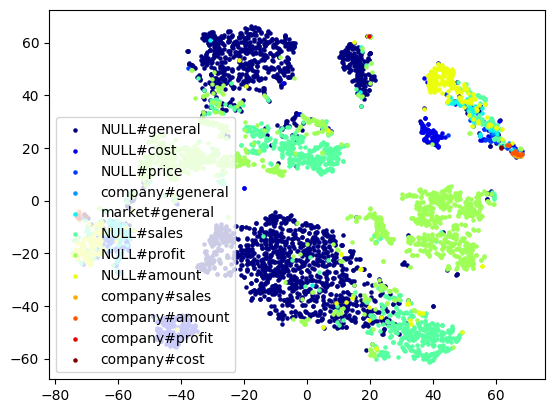

In [ ]:
#プロット
unique_labels = np.unique(category_labels_np)
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))

for i, num_label in enumerate(unique_labels):
    category_name = inverse_mapping_dict[num_label]  # 数値ラベルをカテゴリ名に変換
    plt.scatter(pooler_output_2d[category_labels_np == num_label, 0],
                pooler_output_2d[category_labels_np == num_label, 1],
                color=colors[i],
                label=category_name,
                s=5)

plt.legend()
plt.show()

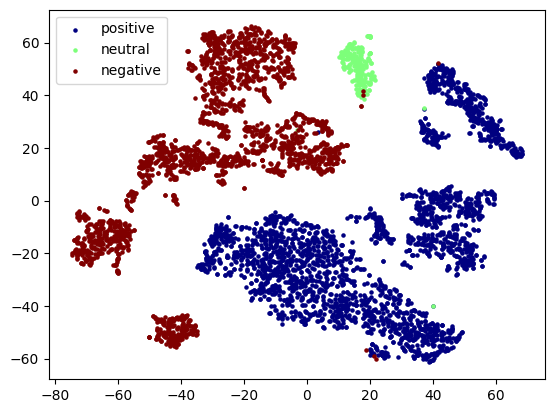

In [ ]:
#プロット
unique_labels = np.unique(pol_labels_np)
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))

for i, num_label in enumerate(unique_labels):
    pol_label = inverse_pol_map[num_label]  # 数値ラベルをカテゴリ名に変換
    plt.scatter(pooler_output_2d[pol_labels_np == num_label, 0],
                pooler_output_2d[pol_labels_np == num_label, 1],
                color=colors[i],
                label=pol_label,
                s=5)

plt.legend()
plt.show()

## confusion matrix

In [ ]:
# モデルを評価モードに切り替える
model.eval()

# 予測と正解のリストを初期化
all_category_preds = []
all_category_labels = []

# DataLoaderからテストデータを1つずつ取り出して予測を行う
for target, sentence, category_labels, pol_labels in train_dataloader:
    category_labels = category_labels.to(device)
    pol_labels = pol_labels.to(device)
    input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)

    with torch.no_grad():
        pred = model(**input)
        all_category_preds.extend(torch.argmax(pred["category_logits"], dim=1).cpu().numpy())
        all_category_labels.extend(category_labels.cpu().numpy())

In [ ]:
from collections import Counter
print(Counter(all_category_preds))
print(Counter(all_category_labels))

Counter({0: 5079, 11: 71})
Counter({0: 2093, 11: 1258, 10: 924, 12: 302, 1: 299, 9: 141, 4: 79, 13: 18, 16: 15, 7: 13, 20: 4, 23: 4})


In [ ]:
# Confusion Matrixの計算
category_cm = confusion_matrix(all_category_labels, all_category_preds)

In [ ]:
# train_categoriesに含まれるカテゴリのみを対象に逆辞書を作成
inverse_mapping_dict_check = {mapping_dict[category]: category for category in train_categories}

# モデルが誤って予測したカテゴリを追加（学習には加えていない）
#inverse_mapping_dict_check[21] = 'product#profit'
inverse_mapping_dict_check[22] = 'product#cost'

print(inverse_mapping_dict_check)

{12: 'NULL#amount', 1: 'NULL#cost', 0: 'NULL#general', 4: 'NULL#price', 11: 'NULL#profit', 10: 'NULL#sales', 16: 'company#amount', 23: 'company#cost', 7: 'company#general', 20: 'company#profit', 13: 'company#sales', 9: 'market#general', 22: 'product#cost'}


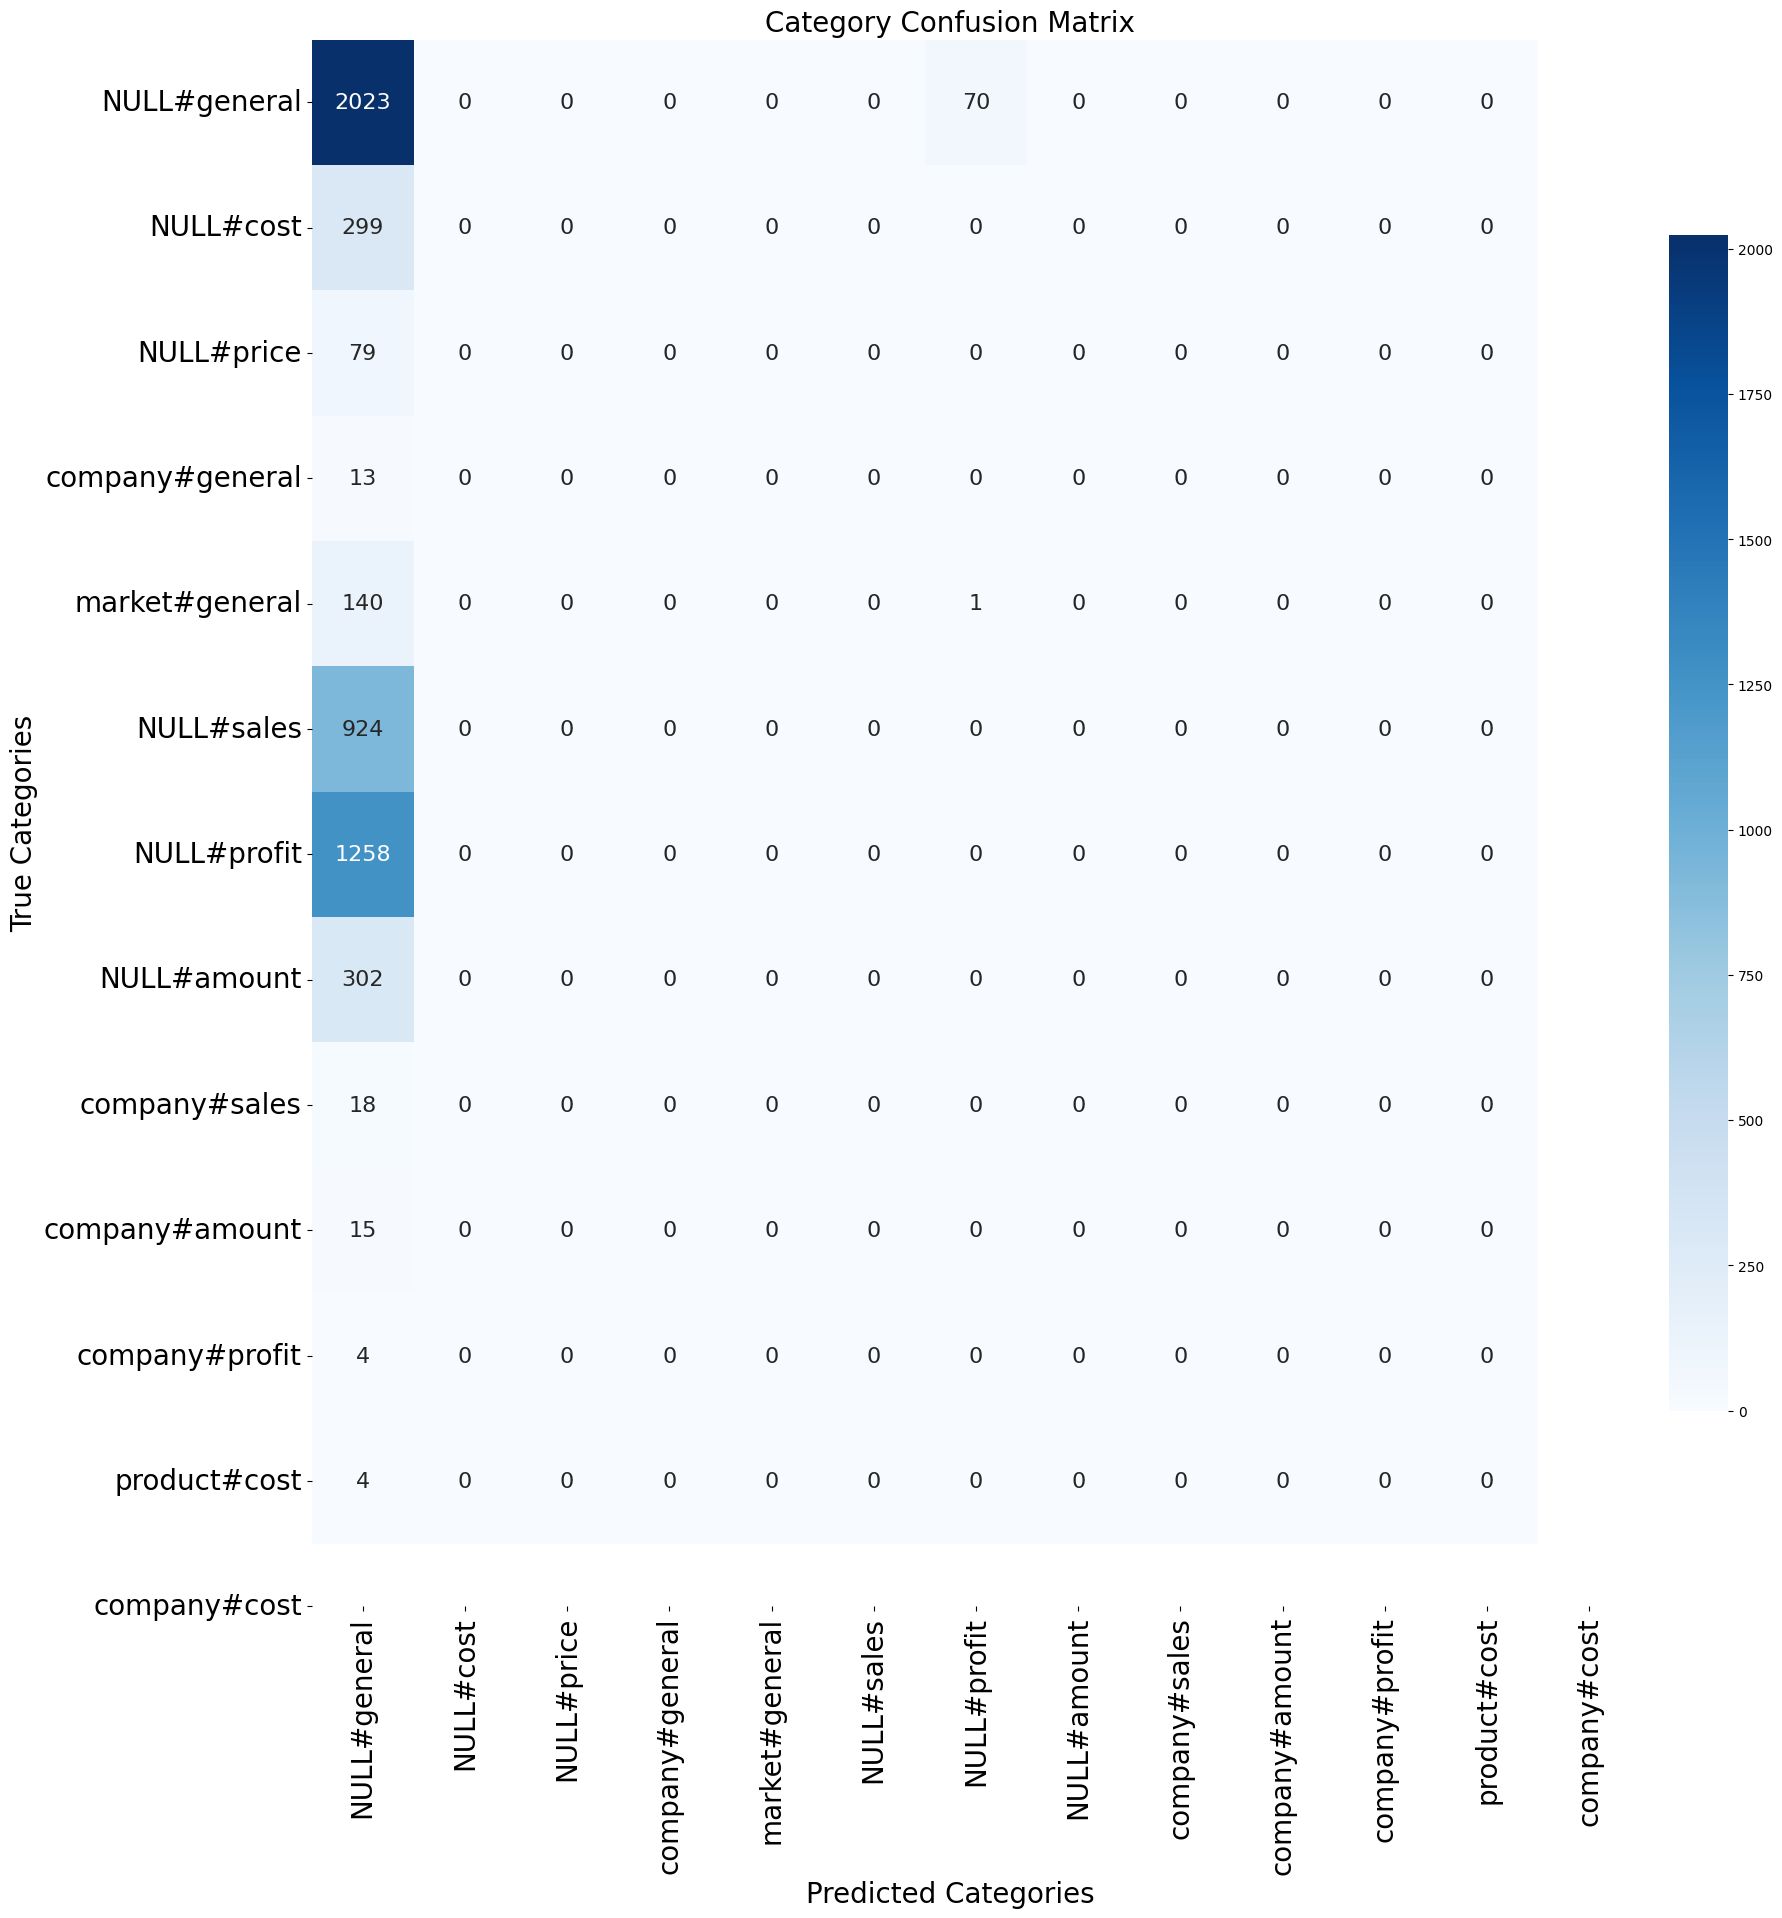

In [ ]:
# Confusion Matrixの計算後...

# カテゴリのConfusion Matrixを表示
category_labels = [inverse_mapping_dict_check[i] for i in sorted(inverse_mapping_dict_check.keys())]
plt.figure(figsize=(18, 18))  # サイズ調整

sns.heatmap(category_cm, annot=True, fmt="", cmap='Blues', xticklabels=category_labels, yticklabels=category_labels, cbar_kws={"shrink": 0.75}, annot_kws={"size": 16})
plt.xlabel('Predicted Categories', fontsize=20)
plt.ylabel('True Categories', fontsize=20)
plt.title('Category Confusion Matrix', fontsize=20)
plt.tight_layout()
plt.xticks(rotation=90, fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.show()

In [ ]:
# モデルを評価モードに切り替える
model.eval()

# 予測と正解のリストを初期化
all_pol_preds = []
all_pol_labels = []

# DataLoaderからテストデータを1つずつ取り出して予測を行う
for target, sentence, category_labels, pol_labels in test_dataloader:
    category_labels = category_labels.to(device)
    pol_labels = pol_labels.to(device)
    input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)

    with torch.no_grad():
        pred = model(**input)
        all_pol_preds.extend(torch.argmax(pred["pol_logits"], dim=1).cpu().numpy())
        all_pol_labels.extend(pol_labels.cpu().numpy())

In [ ]:
# Confusion Matrixの計算
pol_cm = confusion_matrix(all_pol_labels, all_pol_preds)

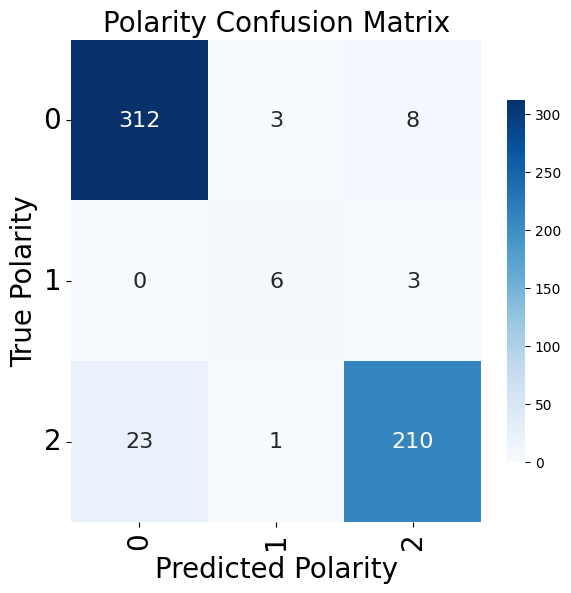

In [ ]:
# Confusion Matrixの計算後...
plt.figure(figsize=(6, 6))  # サイズ調整

sns.heatmap(pol_cm, annot=True, fmt="", cmap='Blues', cbar_kws={"shrink": 0.75}, annot_kws={"size": 16})
plt.xlabel('Predicted Polarity', fontsize=20)
plt.ylabel('True Polarity', fontsize=20)
plt.title('Polarity Confusion Matrix', fontsize=20)
plt.tight_layout()
plt.xticks(rotation=90, fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.show()